# **Unsupervised Learning Methods**
## **Clustering Patient Data: A Comparative Analysis**

**Authors:** Carla Bellido García, Cindy Chen, Celica Krigul, Keith Megara Osores Vicuña, Ema Štangová
  
**Master:** Health Data Science

**Subject:** Machine Learning

**Course:** 2025-2026

---

## **Table of Contents**

**1. [Overview](#section1)**   

**2. [Dataset](#section2)**  
&emsp; **2.1 [Heart Disease UCI Dataset](#section21)**     
&emsp; **2.1 [Features](#section22)**     
  
**3. [Assignment Tasks](#section3)**  
&emsp; **3.1 [Task 1 - Data Loading & Exploration](#section31)**   
&emsp; **3.2 [Task 2 - Preprocessing & Feature Engineering](#section32)**  
&emsp; **3.3 [Task 3 - Clustering: K-Means](#section33)**  
&emsp; **3.3 [Task 4 - Clustering: Gaussian Mixture Models](#section34)**  
&emsp; **3.3 [Task 5 - Clustering: Hierarchical Clustering](#section35)**  
&emsp; **3.3 [Task 6 - Clustering: Evaluation Against Ground Truth](#section36)**   

---
<a id='section1'></a>
## **Overview**

In this assignment, you will apply and compare three unsupervised learning methods - **K-Means Clustering, Gaussian Mixture Models (GMM), and Hierarchical Clustering** - to a real-world medical dataset. Your goal is to discover meaningful patient subgroups *without* using the diagnostic label, then evaluate how well your clusters align with the ground truth once it is revealed.

This mirrors a real challenge in health data science: identifying patient profiles from clinical measurements alone, before a diagnosis is available. The skills you practice here - preprocessing, dimensionality reduction,  clustering, and evaluation - form the backbone of many unsupervised pipelines in healthcare.

---
<a id='section2'></a>
## **Dataset**

<a id='section21'></a>
### **Heart Disease UCI Dataset**

You will work with the Heart Disease dataset from the UCI Machine Learning Repository, publicly available at: https://archive.ics.uci.edu/dataset/45/heart+disease 

The dataset (use only processed.cleveland.data) contains 303 patient records with 13 clinical features and one target variable. You must treat the target variable as hidden during clustering, and only use it for evaluation afterwards.

<a id='section22'></a>
### **Features**

|**Feature** |**Name**                |**Description**                                             |  
|------------|------------------------|------------------------------------------------------------|  
|``age``     |Age                     |Age in years                                                |  
|``sex``     |Sex                     |1 = male, 0 = female                                        |  
|``cp``      |Chest pain type         |4 types (0-3)                                               |  
|``trestbps``|Resting blood pressure  |mm Hg on admission                                          |  
|``chol``    |Serum cholesterol|mg/dl |mg/dl                                                       |  
|``fbs``     |Fasting blood sugar     | >120mg/dl: 1 = true, 0 = false                             |  
|``restecg`` |Resting ECG results     |Values 0, 1, 2                                              |  
|``thalach`` |Max heart rate achieved |Numeric                                                     |  
|``exang``   |Exercise-induced angina |1 = yes, 0 = no                                             |  
|``oldpeak`` |ST depression           |Induced by exercise vs. rest                                |  
|``slope``   |Slope of peak ST segment|Values 0, 1, 2                                              |  
|``ca``      |Major vessels (0-3)     |Coloured by fluoroscopy                                     |  
|``thal``    |Thal                    |3 = normal, 6 = fixed defect, 7 = reversible defect         |  
|``target``  |**Diagnosis (HIDDEN)**  |*0 = no disease, 1-4 = disease present. Binarise as 0 vs 1+*|  

---
<a id='section3'></a>
## **Assignment Tasks**

The assignment follows a single end-to-end pipeline. All team members should understand every stage, even if responsibilities are divided.

<a id='section31'></a>
### **Task 1 - Data Loading & Exploration**

In [222]:
# Libraries used
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

- Load the dataset and display its shape, data types, and summary statistics.

In [223]:
# Criteria: Data loaded correctly; shape, dtypes, and nulls reported.

# Load dataset
df = pd.read_csv("data/processed.cleveland.data", header=None)
print(df.shape)
print(df.head())
print(df.dtypes)

df.replace("?", pd.NA, inplace=True)
print(df.isnull().sum())



(303, 14)
     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11        str
12        str
13      int64
dtype: object
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    4
12    2
13    0
dtype: int64


We used the **shape** function to confirm the size of the dataset. The output shows that the dataset contains 303 rows and 14 columns.

Next, we used the **head()** function to preview the first rows of the dataset and understand what kind of data it contains. From this output we can see that the dataset has 14 columns, and most of the values are numerical. The **dtypes** function was then used to display the data types of each column, confirming the previously observed distribution of variable types.Columns 0–10 are of type float, columns 11–12 are object, and column 13 is an integer.

Finally, we used **isnull().sum()** to count the number of missing values in each column. Before performing this check, the symbol "?" was replaced with NaN, since pandas does not interpret "?" as a missing value by default. Without this conversion, the dataset initially appeared to contain no missing values. After the replacement, the analysis revealed 4 missing values in the ca variable and 2 missing values in the thal variable, which will need to be handled during preprocessing.

In [224]:
# Add column names
cols = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

df.columns = cols
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [225]:
# convert to numeric 
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

- Identify and handle missing values. Document your strategy and justify it.

We examined the values of both categorical and continuous variables to ensure that they fall within the expected and realistic ranges defined in the dataset documentation.

In [226]:
# Check unique values for categorical/binary variables
print("sex:", df["sex"].unique())
print("cp:", df["cp"].unique())
print("fbs:", df["fbs"].unique())
print("restecg:", df["restecg"].unique())
print("exang:", df["exang"].unique())
print("slope:", df["slope"].unique())
print("ca:", df["ca"].unique())
print("thal:", df["thal"].unique())
print("target:", df["target"].unique())

# Check basic ranges for continues variables 
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe()

sex: [1. 0.]
cp: [1. 4. 3. 2.]
fbs: [1. 0.]
restecg: [2. 0. 1.]
exang: [0. 1.]
slope: [3. 2. 1.]
ca: [ 0.  3.  2.  1. nan]
thal: [ 6.  3.  7. nan]
target: [0 2 1 3 4]


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


The maximum resting blood pressure (trestbps) is 200 mmHg, which corresponds to a hypertensive crisis, indicating a critically high value. [heart.org](https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings#:~:text=Use%20our%20blood%20pressure%20chart%20to%20learn,and%20the%20difference%20between%20systolic%20and%20diastolic.)

The variable chol (serum cholesterol) has a maximum value of 564 mg/dl, which is significantly higher than the recommended threshold. This indicates a case of severe hyperlipidemia. [clevelandclinic.org](https://my.clevelandclinic.org/health/diseases/21656-hyperlipidemia)

A common approximation for maximum heart rate is 220 − age. In our dataset, the youngest patient is 29 years old, giving an estimated maximum heart rate of 191 bpm. However, the dataset reports a maximum thalach value of 202 bpm, which exceeds this estimate even if it belonged to the youngest patient. This suggests a potential extreme observation. [heart.org](https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates#:~:text=Your%20maximum%20heart%20rate%20is,70%2D85%25%20of%20maximum.)

The variable oldpeak represents ST depression induced by exercise relative to rest. A value of 0.0 indicates no measurable ST depression, which is clinically possible. However, the maximum value 6.2 is unusually high and may represent an extreme observation, potentially related to severe ischemia during stress testing. [ecgwaves.com](https://ecgwaves.com/st-segment-normal-abnormal-depression-elevation-causes/?utm_source=chatgpt.com)

In [227]:
# taking continuous (numeric) features to identify outliers 
cols_continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

outlier_list = []

for col in cols_continuous:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)

    for idx in df[mask].index:
        outlier_list.append({
            'column': col,
            'index': idx,
            'value': df.loc[idx, col]
        })

outliers_df = pd.DataFrame(outlier_list)

In [228]:
outliers_df

,column,index,value
0,trestbps,14,172.0
1,trestbps,83,180.0
2,trestbps,126,200.0
3,trestbps,172,174.0
4,trestbps,183,178.0
5,trestbps,188,192.0
6,trestbps,201,180.0
7,trestbps,213,178.0
8,trestbps,231,180.0
9,chol,48,417.0


The detected outliers using the IQR method correspond closely with clinically extreme values identified through domain knowledge. For example, very high resting blood pressure (up to 200 mmHg) and cholesterol levels (up to 564 mg/dl) are both statistically and medically significant, representing severe pathological conditions rather than data errors. However, not all clinically unusual values are captured by statistical methods. For instance, this method identifies unusually low heart rate values as outliers.
Since the subsequent analysis involves clustering methods such as K-means, Gaussian Mixture Models, and hierarchical clustering, the dataset will be scaled to ensure comparability between features. Rather than removing outliers, these extreme values will be retained, as they likely represent meaningful high-risk patient profiles. Their inclusion allows the clustering algorithms to capture clinically important subgroups within the data.

In [229]:
# why and where the missing values happen?
df[df.isnull().any(axis=1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


We observe that the missing values occur in different rows, which suggests that they may be missing because the diagnostic tests were not performed or the results were not recorded during data collection. Instead of removing these observations, we chose to apply imputation in order to preserve the dataset size. Since the variables contain discrete integer values, the median was selected as an appropriate method for filling the missing values.

In [230]:
# convert to numeric 
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

# median imputation 
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

#control
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

- Plot distributions of all features (histograms, box plots).

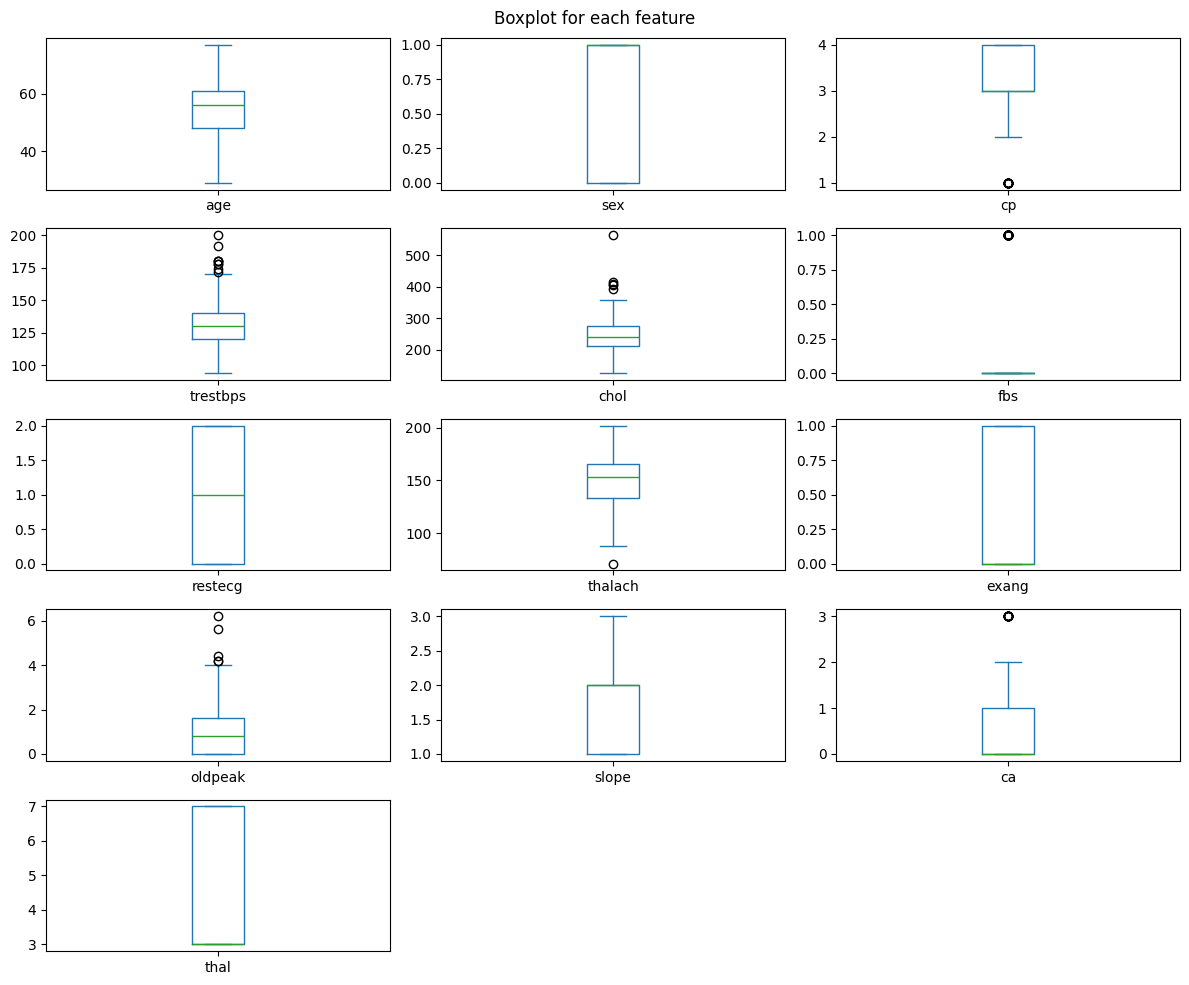

In [231]:
# Criteria: Histograms/box plots for all features. Observations discussed in markdown.
# Boxplots for all features
df.drop("target", axis=1).plot(
    kind="box",
    subplots=True,
    layout=(5,3),
    sharex=False,
    sharey=False,
    figsize=(12,10),
    title="Boxplot for each feature"
)

plt.tight_layout()
plt.show()

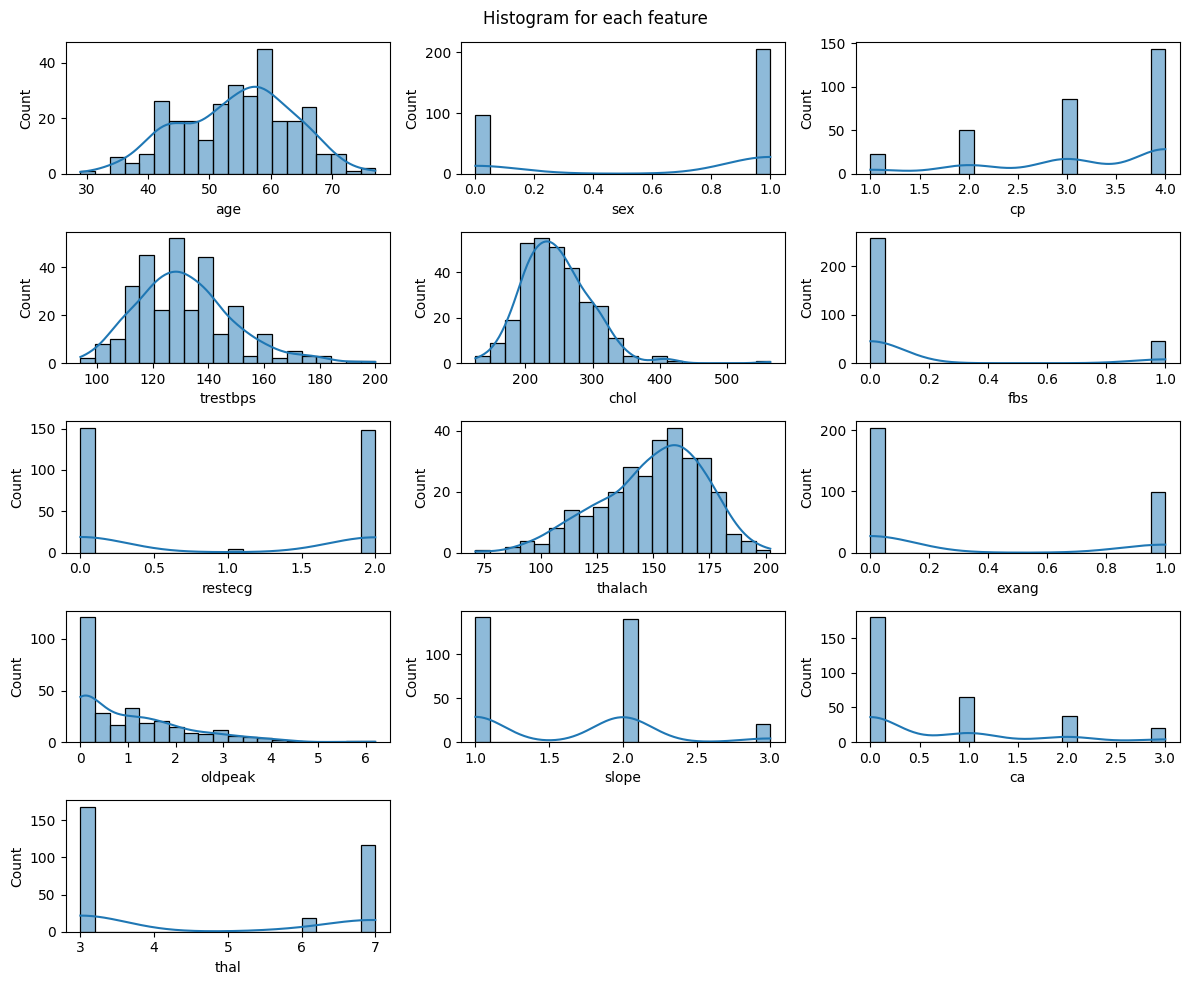

In [232]:
# histograms for all features
features = df.drop("target", axis=1)

fig, axs = plt.subplots(5,3, figsize=(12,10))
axs = axs.ravel()

for i, col in enumerate(features.columns):
    sns.histplot(data=df,x=col, ax=axs[i], kde=True, bins = 20)

for j in range(len(features.columns), len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Histogram for each feature")
plt.tight_layout()
plt.show()

<Axes: xlabel='oldpeak', ylabel='Count'>

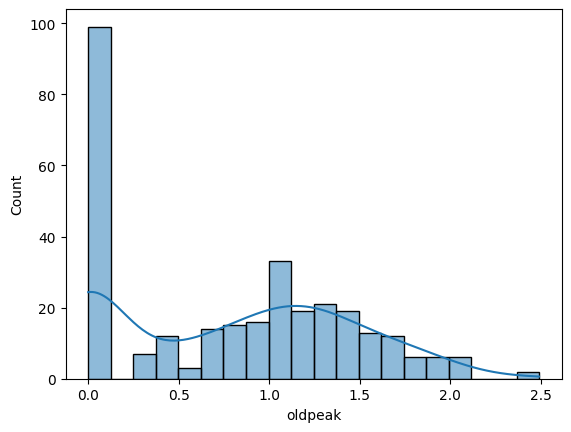

In [233]:
sns.histplot(x=np.sqrt(df['oldpeak']), kde=True, bins = 20)

Histograms and boxplots were used to analyze the distribution of all features and identify potential outliers. The continuous variables (age, trestbps, chol, thalach, and oldpeak) show wider distributions and several potential outliers, particularly in chol, trestbps, and oldpeak.

In contrast, variables such as: sex, fbs, and exang are binary, while: cp, restecg, slope, ca, and thal are categorical, which results in discrete distributions. These observations are consistent with the expected structure of the dataset and help inform further preprocessing steps for machine learning.

- Plot a correlation heatmap. Discuss which features appear most related.

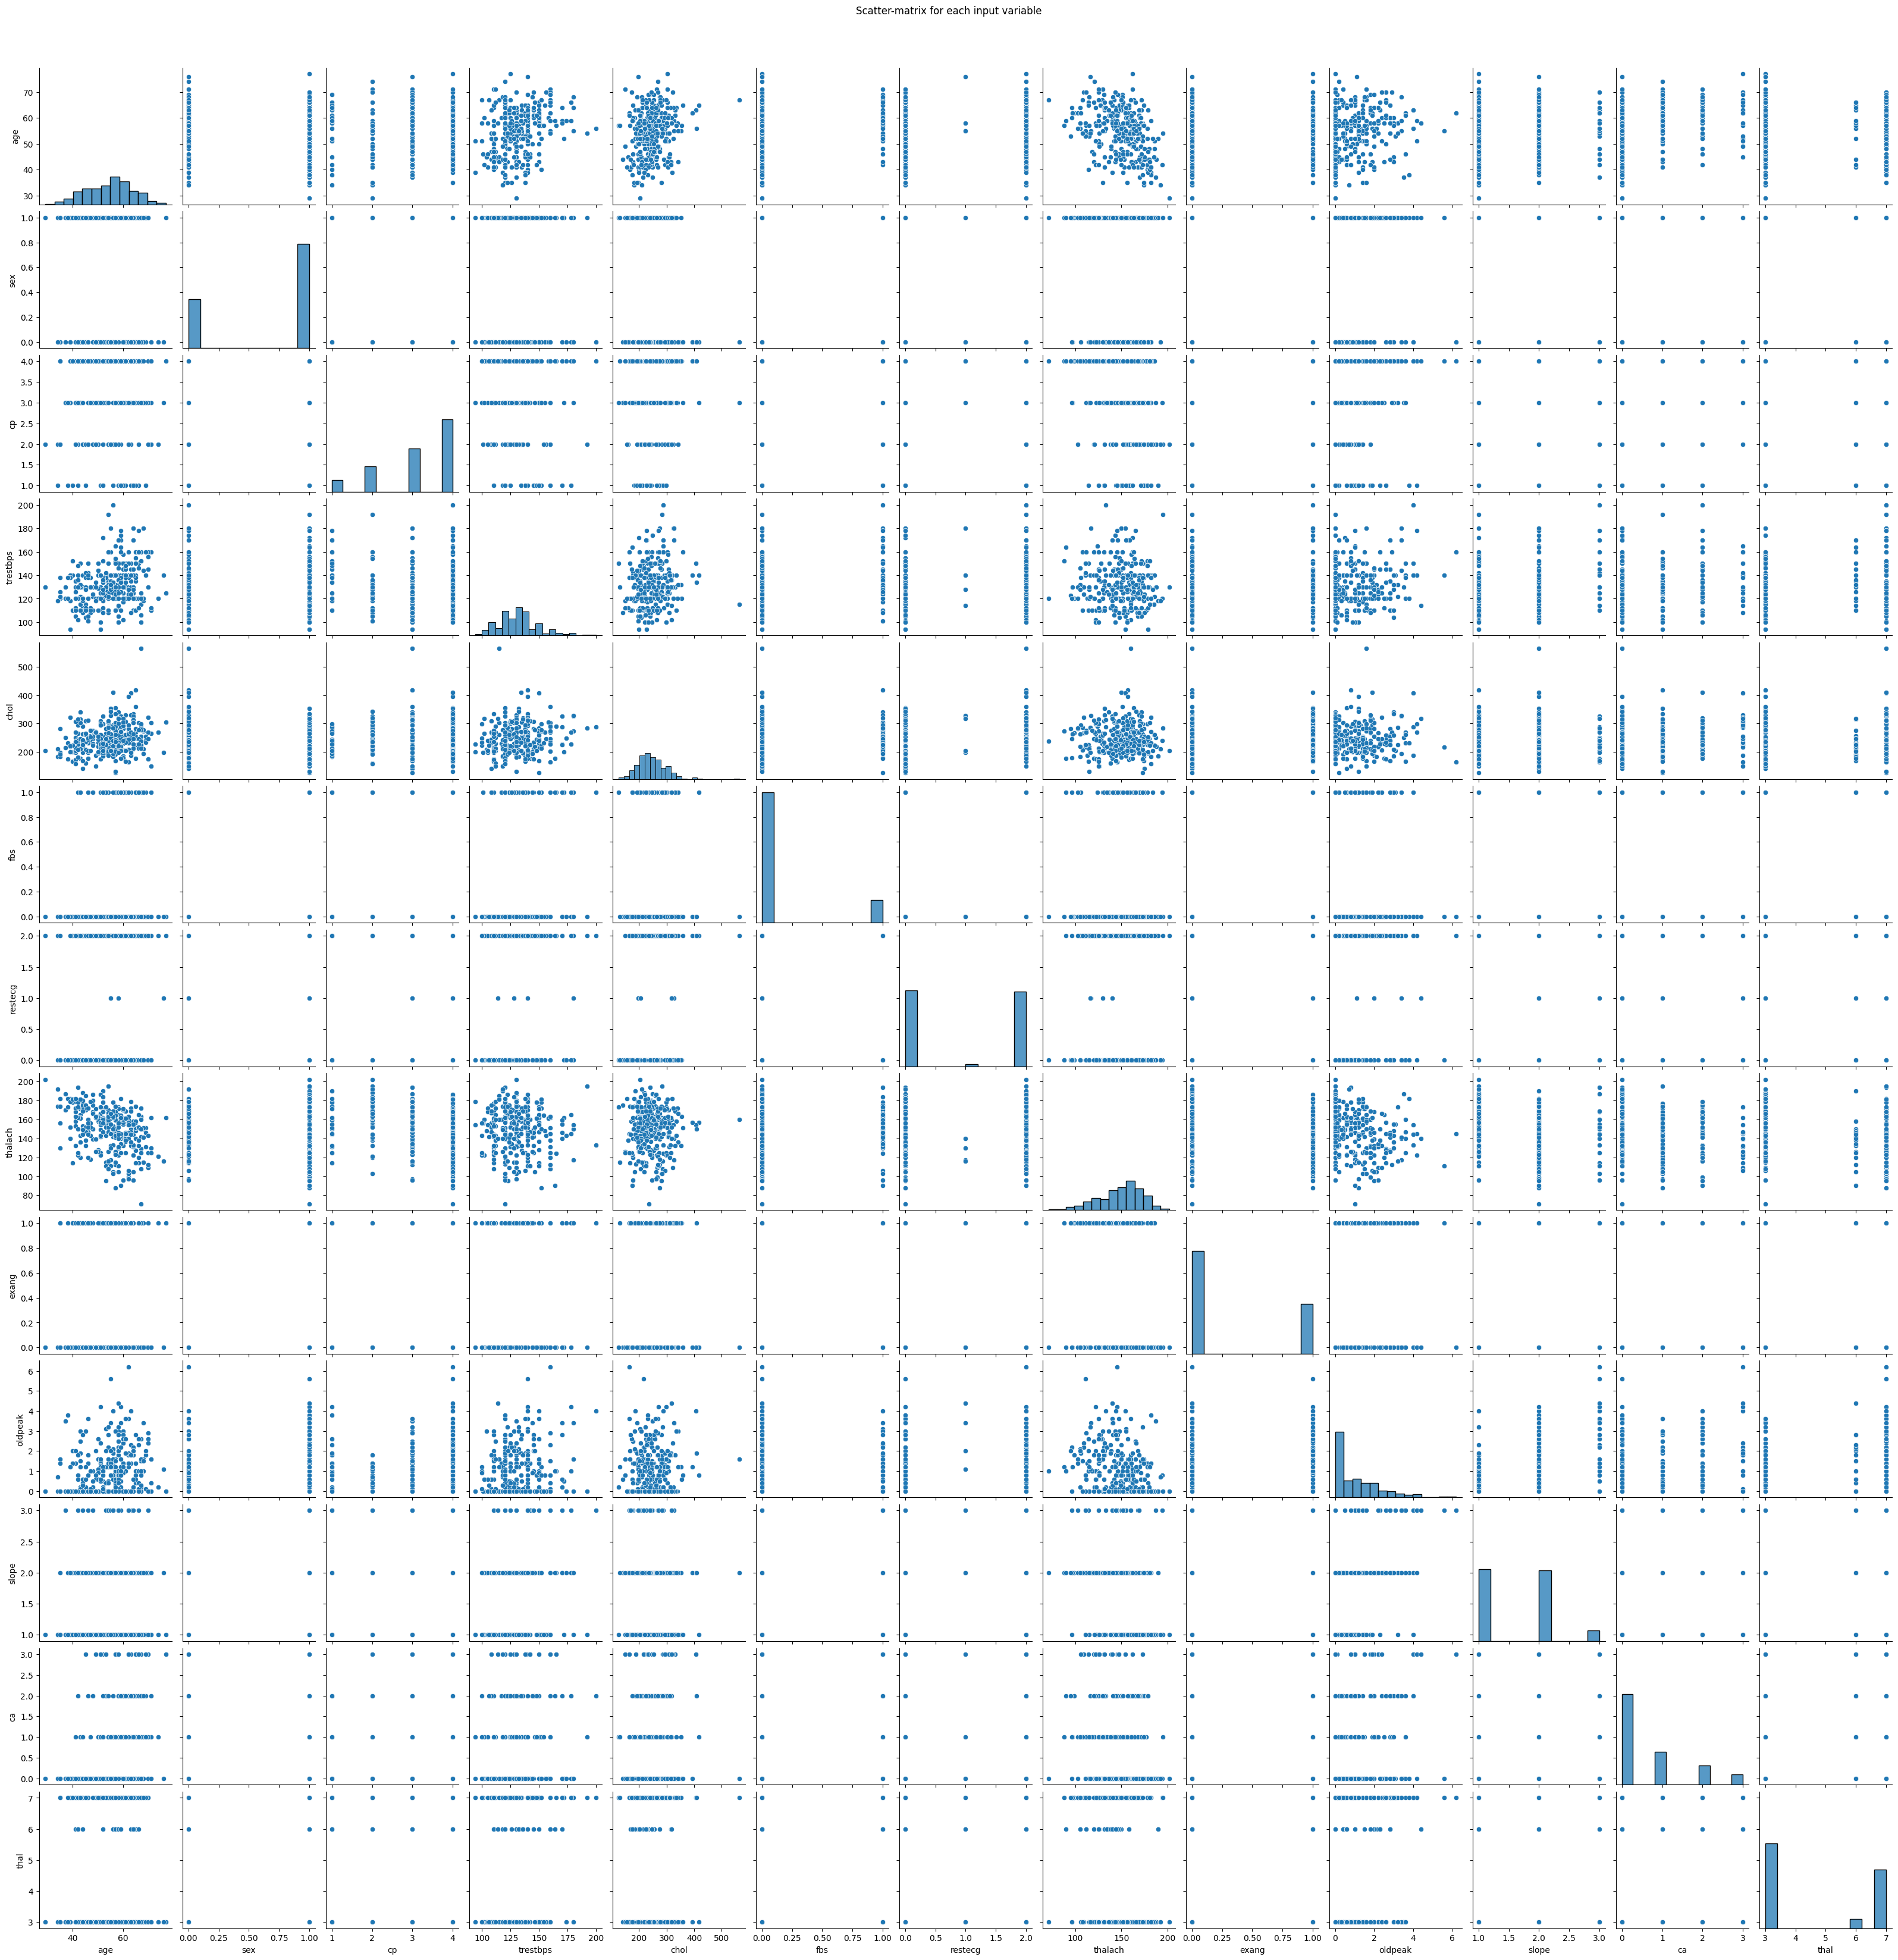

In [234]:
# Criteria: Heatmap present. Notable correlations identified and discussed.
corr = sns.pairplot(df.drop("target", axis=1), diag_kind="hist")

corr.fig.suptitle("Scatter-matrix for each input variable", y=1.02)

plt.show()


Most features show weak or no clear linear relationships, indicating low overall correlation between variables.
One noticeable pattern is a negative relationship between age and thalach, suggesting that older patients tend to achieve lower maximum heart rates.
The scatter matrix includes both continuous and categorical variables. Categorical variables produce banded patterns due to their discrete values, while meaningful correlations are mainly observed among the continuous variables.

- Keep the target column separate and do not use it during clustering.

The target variable is kept separately and will be used later for evaluation purposes.
| Variable            |  meaning                                             |
| ------------------- | --------------------------------------------------- |
| **clustering_data** | data used to create clusters (without target column)                        |
| **evaluation_data** | target labels used later to evaluate the clustering |


In [235]:
clustering_data = df.drop("target", axis=1)
evaluation_data = df["target"]

In [236]:
#controlling columns
print(clustering_data.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')


<a id='section32'></a>
### **Task 2 - Preprocessing & Feature Engineering**

- Encode categorical features appropriately.

As given above, the categorical variables in this dataset are: sex, cp, fbs, restecg, exang, slope and thal. Which tactic to choose depends on whether the categories of our features are ordered or not. We should create dummy variables for all these features as there is no order, no relationship between the values chosen to represent the different categories.

In [237]:
# Criteria: Correct encoding. Scaling method justified.

cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
#clustering_data_enc = pd.get_dummies(clustering_data, columns=cat_cols, drop_first=True)

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(clustering_data[cat_cols])

clustering_data_enc = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cat_cols))
clustering_data_enc = pd.concat([clustering_data.drop(cat_cols, axis=1), clustering_data_enc], axis=1)

In [238]:
clustering_data_enc.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex_0.0', 'sex_1.0',
       'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0',
       'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'exang_0.0', 'exang_1.0',
       'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0', 'ca_2.0',
       'ca_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='str')

- Normalise or standardise features. Justify your choice of method.

For normalising/standardising we should first look at the data distribution of all the numerical columns.

- age, thalach: the column is approximately Gaussian distributed -> standardise
- trestbps, chol, oldpeak: values are right skewed -> log transformation and standardise

In [239]:
num_cols1 = ['age', 'thalach']
num_cols2 = ['trestbps', 'chol']
num_cols3 = ['oldpeak']
#log_num_cols2 = [f'log_{col}' for col in num_cols2]
#sqrt_num_cols3 = [f'sqrt_{col}' for col in num_cols3]

#scaler1 = StandardScaler()
#clustering_data_enc[num_cols1] = scaler1.fit_transform(clustering_data_enc[num_cols1])

clustering_data_enc[num_cols2] = np.log1p(clustering_data_enc[num_cols2])
#scaler2 = StandardScaler()
#clustering_data_enc[log_num_cols2] = scaler2.fit_transform(clustering_data_enc[log_num_cols2])

clustering_data_enc[num_cols3] = np.sqrt(clustering_data_enc[num_cols3])

scaler = StandardScaler()
clustering_data_enc[num_cols1+num_cols2+num_cols3] = scaler.fit_transform(clustering_data_enc[num_cols1+num_cols2+num_cols3])

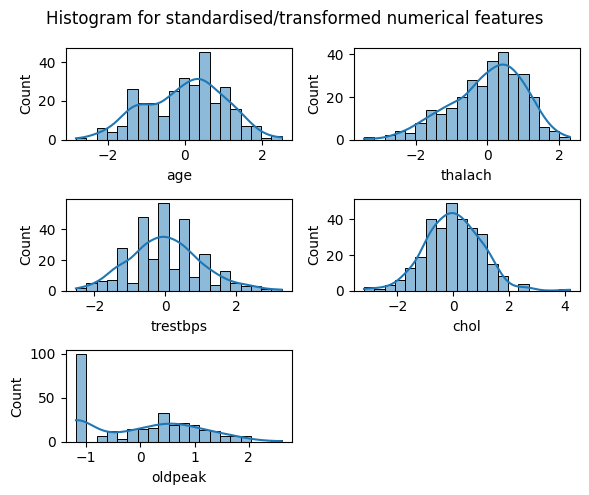

In [240]:
# histograms for normalised/standardised numerical features
features = clustering_data_enc[num_cols1+num_cols2+num_cols3]
fig, axs = plt.subplots(3,2, figsize=(6,5))
axs = axs.ravel()

for i, col in enumerate(features.columns):
    sns.histplot(data=clustering_data_enc,x=col, ax=axs[i], kde=True, bins = 20)

for j in range(len(features.columns), len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Histogram for standardised/transformed numerical features")
plt.tight_layout()
plt.show()

**Step A - PCA:**

*Note:* PCA is used here for visualisation purposes only. Clustering in Tasks 3–5 will be performed on the scaled feature set selected in Step B.

- Plot the explained variance ratio per component and cumulatively.

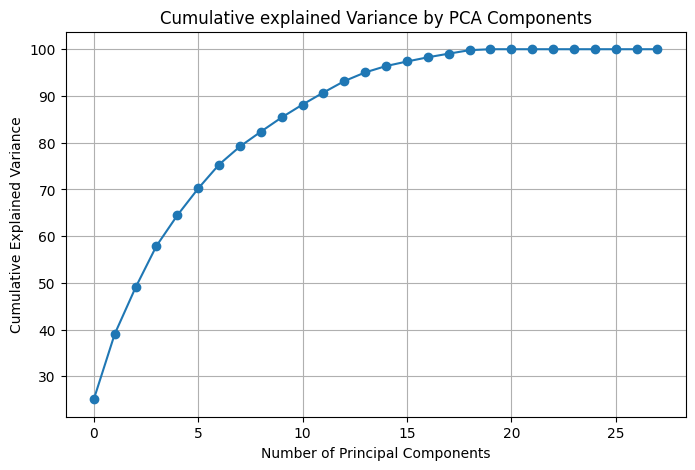

In [241]:
X = clustering_data_enc#.drop(['trestbps', 'chol', 'oldpeak'], axis=1)

pca = PCA()
pca.fit(X)

# plot cumulative explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum((pca.explained_variance_ratio_)*100), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative explained Variance by PCA Components')
plt.grid(True)
plt.show()

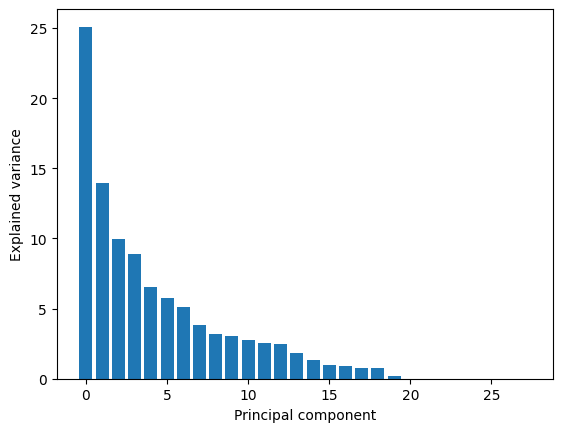

In [242]:
# plot individual explained variance ratio
plt.bar(range(len(pca.explained_variance_ratio_)), (pca.explained_variance_ratio_)*100)
plt.xlabel('Principal component')
plt.ylabel('Explained variance')
plt.show()

- Select the number of components that explain at least 85% of variance.

In [243]:
X = clustering_data_enc#.drop(['trestbps', 'chol', 'oldpeak'], axis=1)
pca = PCA(n_components=0.85)
pca.fit_transform(X)
loadings = pd.DataFrame(abs(pca.components_.T), 
                        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                        index=X.columns)

print("These are the calculated components: \n", pca.components_) # The PCA object now contains useful information in its attributes. components_ stores the principal components calculated
print("The components we have found, explain the following percentage of variance: \n", pca.explained_variance_ratio_) # explained_variance_ratio_ stores the percentage of variance each of our components explains
print('The number of components that explain at least 85% of variance: \n', len(pca.explained_variance_ratio_))

These are the calculated components: 
 [[-4.35941087e-01 -2.44511082e-01 -1.50133342e-01  4.98991232e-01
  -4.85387748e-01  2.32092284e-02 -2.32092284e-02 -5.64252380e-03
   8.93808414e-02  6.97651129e-02 -1.53503431e-01  2.38624980e-02
  -2.38624980e-02  8.63643705e-02 -1.08741988e-02 -7.54901718e-02
   1.48031108e-01 -1.48031108e-01  2.03720783e-01 -1.75367997e-01
  -2.83527858e-02  1.47991459e-01 -5.20932521e-02 -5.66582826e-02
  -3.92399241e-02  1.61004567e-01 -2.59233684e-02 -1.35081198e-01]
 [ 3.28676062e-01  5.07039690e-01  6.03516787e-01  2.75123388e-01
  -2.21618367e-01  1.47074308e-01 -1.47074308e-01  1.62118111e-02
   3.85191530e-02  3.58664820e-02 -9.05974461e-02 -4.30738301e-02
   4.30738301e-02 -9.74806980e-02  1.39098982e-04  9.73415990e-02
   9.92104979e-02 -9.92104979e-02  1.23303419e-01 -1.10034691e-01
  -1.32687280e-02 -1.05303524e-03 -2.42746060e-02  1.80575530e-02
   7.27008818e-03  1.10956969e-01 -2.35237410e-02 -8.74332277e-02]
 [-6.03013434e-02  7.17290677e-01 -

- Visualise the data in the first two principal components.

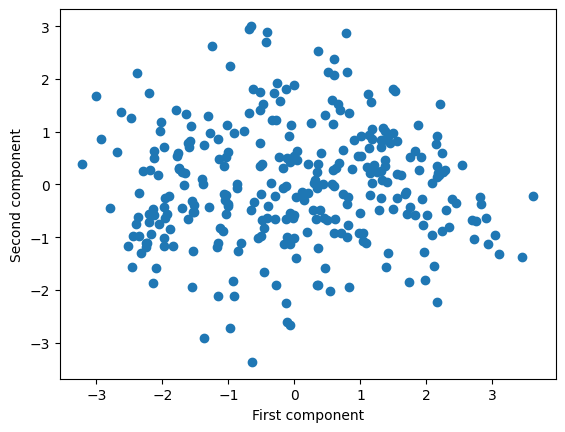

In [244]:
X = clustering_data_enc#.drop(['trestbps', 'chol', 'oldpeak'], axis=1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel('First component')
plt.ylabel('Second component')
plt.show()

In [213]:
# Criteria: Variance plot correct. Component count justified. 2D scatter shown.

**Step B - Feature selection:**

- Split the data into training and test sets before applying feature selection. This is the only step where the target label may be used - supervised feature selection methods (as covered in the course) require it. The test set and the target label must not be used again after this point.

In [245]:
X = clustering_data_enc#.drop(['trestbps', 'chol', 'oldpeak'], axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, evaluation_data, test_size=0.2, shuffle=True, random_state=42)

In [246]:
X

,age,trestbps,chol,thalach,oldpeak,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,...,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.804148,-0.179214,0.017197,1.122062,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.392002,1.559828,0.830366,-1.821905,0.677069,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1.392002,-0.647099,-0.264475,-0.902354,1.268258,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.932564,-0.033526,0.167589,1.637359,1.662241,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.489288,-0.033526,-0.833495,0.980537,0.613744,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,-1.313630,0.435989,-0.770990,0.479908,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
299,1.502821,0.751042,-1.106222,-0.376896,1.621193,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
300,0.283813,-0.033526,-3.010333,-1.515388,0.479908,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
301,0.283813,-0.033526,-0.116220,1.068113,-1.190466,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


- Apply at least one feature selection method covered in the course on the training set.

In [247]:
# Configure to select all features
fs1 = SelectKBest(score_func=f_classif, k = 'all')
# Learn relationship from training data
fs1 = fs1.fit(X_train, Y_train)
# Transform train data
X_train_fs = fs1.transform(X_train)
# Transform test data
X_test_fs = fs1.transform(X_test)

In [248]:
# Get the pvalues
kbest_scores = -np.log10(fs1.pvalues_)
cols = fs1.get_support(indices=True)
# Selected_columns
print(cols)
# Normalize
kbest_scores /= kbest_scores.max()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27]


Number of features: 17


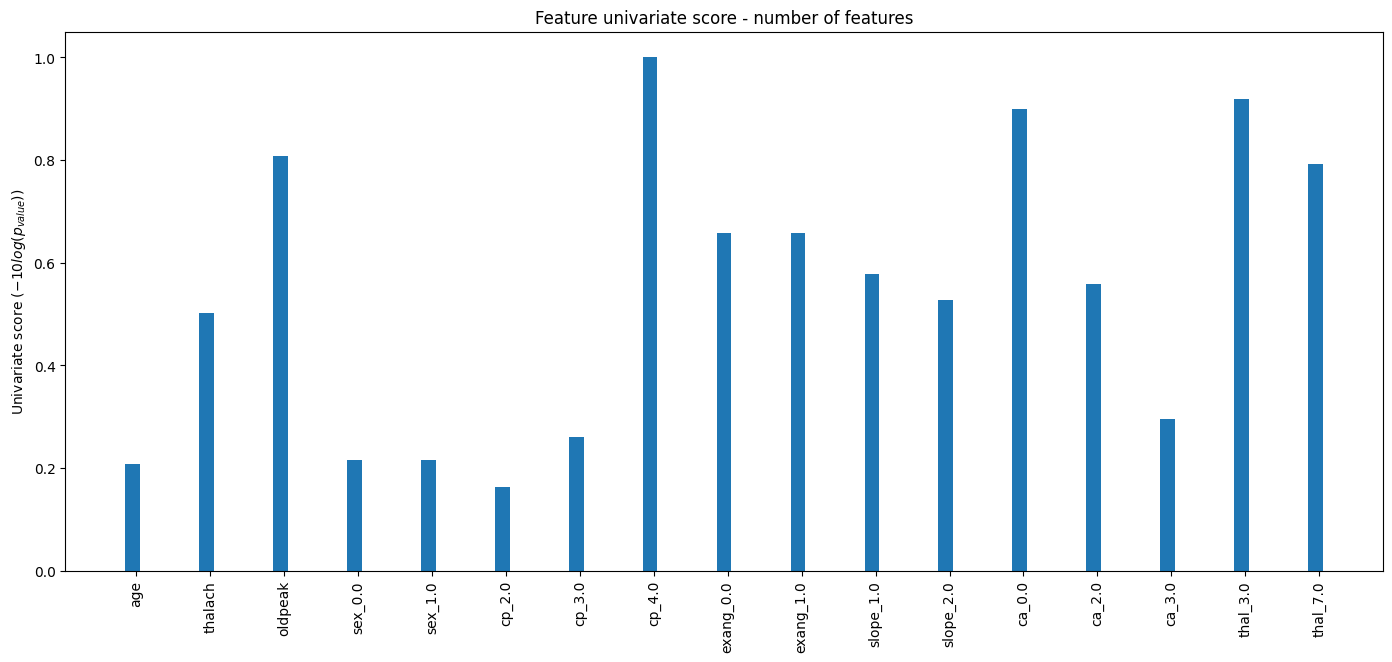

In [254]:
# Keep only the features with p-value below a threshold
cols = np.where(fs1.pvalues_<0.005)[0]
temp = X_train.iloc[:,cols]
X_indices = np.arange(temp.shape[-1])
print("Number of features:", temp.shape[1])
# Create the plot
plt.figure(figsize=(17,7))
plt.figure(1)
plt.clf()
plt.bar(X_indices - 0.05, kbest_scores[cols], width=0.2)
plt.title("Feature univariate score - number of features")
plt.xticks(range(0,len(cols)),X_train.columns[cols], rotation=90)
plt.ylabel("Univariate score ($-10 log(p_{value})$)")
plt.show()

- Compare the selected feature subset with the components identified by PCA. Do they capture similar structure?

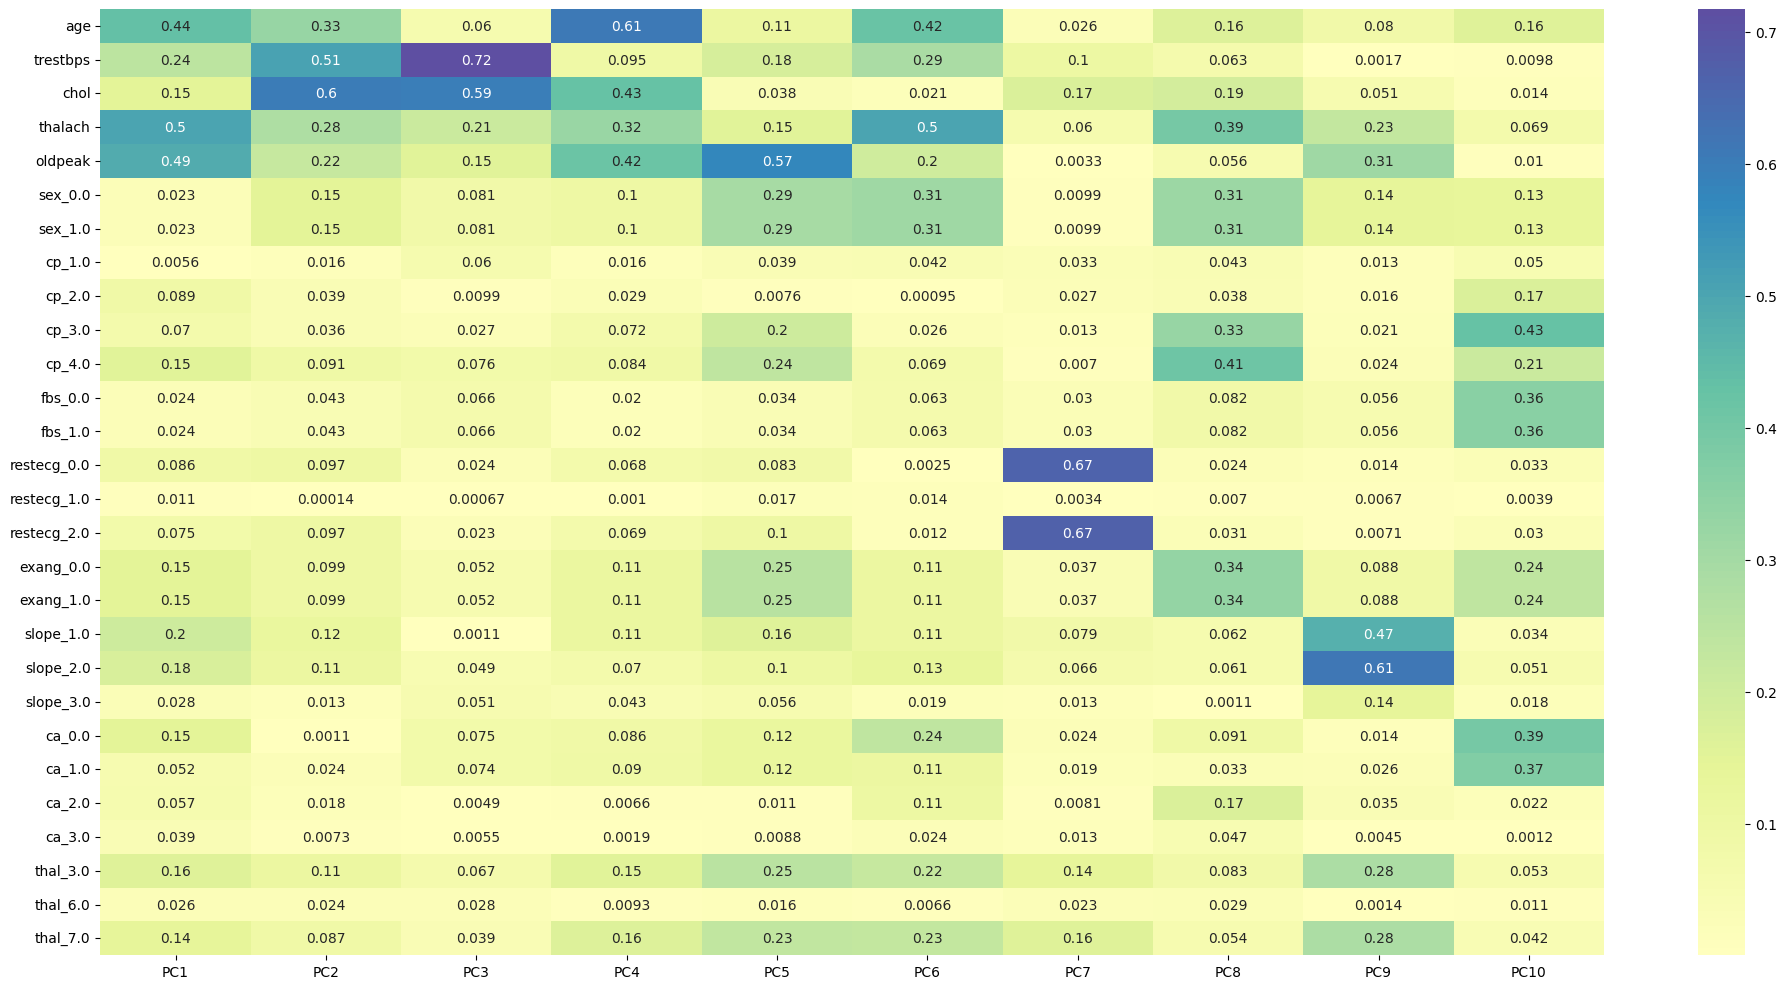

In [250]:
plt.figure(figsize=(20, 10))
sns.heatmap(loadings, annot=True, cmap='Spectral', center=0)
plt.tight_layout()
plt.show()

In [251]:
loadings['sum'] = loadings['PC1'] + loadings['PC2'] + loadings['PC3'] + loadings['PC4'] + loadings['PC5'] + loadings['PC6'] + loadings['PC7'] + loadings['PC8'] + loadings['PC9'] + loadings['PC10']
loadings.sort_values('sum', ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,sum
thalach,0.498991,0.275123,0.209797,0.320584,0.154397,0.501216,0.059541,0.392720,0.225877,0.068796,2.707042
oldpeak,0.485388,0.221618,0.153280,0.417064,0.571846,0.199470,0.003332,0.056156,0.313056,0.010155,2.431365
age,0.435941,0.328676,0.060301,0.610283,0.107838,0.422185,0.026232,0.162877,0.079518,0.160903,2.394754
chol,0.150133,0.603517,0.594114,0.430767,0.037757,0.021473,0.170209,0.185529,0.051353,0.013835,2.258686
trestbps,0.244511,0.507040,0.717291,0.094816,0.181525,0.288719,0.102937,0.062598,0.001680,0.009843,2.210960
sex_1.0,0.023209,0.147074,0.081015,0.100432,0.292018,0.312651,0.009881,0.314141,0.135634,0.132645,1.548700
sex_0.0,0.023209,0.147074,0.081015,0.100432,0.292018,0.312651,0.009881,0.314141,0.135634,0.132645,1.548700
thal_3.0,0.161005,0.110957,0.067134,0.154815,0.248937,0.222240,0.135453,0.082868,0.280563,0.052899,1.516871
exang_1.0,0.148031,0.099210,0.051994,0.114671,0.253323,0.108151,0.037445,0.336157,0.087791,0.239678,1.476453
exang_0.0,0.148031,0.099210,0.051994,0.114671,0.253323,0.108151,0.037445,0.336157,0.087791,0.239678,1.476453


The most important features according to KBest: cp_4.0, ca_0.0, thal_3.0, oldpeak, thal_7.0.
The most important features according to PCA: thalach, oldpeak, age, chol, trestbps.

- Justify which features you will retain for clustering, and why.

The difference between the features identified by SelectKBest and PCA can be explained due to PCA not handling (encoded) categorical features very well. PCA is designed to work on numerical data and therefore, even though we technically can use (encoded) categorical columns in the analysis, the relationships are not really learnt very well.
Therefore, for clustering we propose retaining the variables cp, ca, thal, oldpeak, age, chol, trestbps and thalach, as these are the top5 features identified by the two methods.

In [59]:
# Criteria: At least one method applied. Comparison with PCA discussed.
## Final representation justified.



<a id='section33'></a>
### **Task 3 - Clustering: K-Means**

- Apply K-Means for values of k from 2 to 10.

- Use the Elbow Method (inertia / cost) to identify the optimal k.

- Also compute the Silhouette Score for each k and plot it.

In [60]:
# Criteria: Both plots produced and interpreted.
## Optimal k selected with justification.



- Fit the final K-Means model with your chosen k and visualize the clusters in PCA space.

In [61]:
# Criteria: Cluster assignments plotted in PCA space. Centres reported.



- Visualise the cluster assignments by projecting the data into PCA space (2D). Report and interpret the cluster centres directly in the original feature space, which features are highest or lowest for each group?

In [62]:
# Criteria: Feature-level description of each cluster provided.



<a id='section34'></a>
### **Task 4 - Clustering: Gaussian Mixture Models**

- Fit GMMs with a varying number of components (2 to 10).

- Use BIC or AIC to select the optimal number of components. Plot the selected method curve.

In [63]:
# Criteria: Both curves plotted. Optimal components selected and justified.



- Visualise the cluster assignments by projecting the data into PCA space (2D). Report and interpret the cluster centres directly in the original feature space, which features are highest or lowest for each group?

In [64]:
# Criteria: Cluster assignments plotted in PCA space. Centres reported.



- Compare the hard cluster assignments from GMM with K-Means. Where do they agree and disagree?

In [65]:
# Criteria: Agreements and disagreements discussed with examples.



<a id='section35'></a>
### **Task 5 - Clustering: Hierarchical Clustering**

- Compute a dendrogram using at least two linkage methods (e.g. Ward, complete, average).

In [66]:
# Criteria: Two linkage methods compared. Dendrogram plotted clearly.



- Choose a cut point on the dendrogram and justify your choice.

In [67]:
# Criteria: Cut justified. Clusters visualised in PCA space.



- Visualise the cluster assignments by projecting the data into PCA space (2D). Report and interpret the cluster centres directly in the original feature space, which features are highest or lowest for each group?.

- Discuss how hierarchical clustering differs structurally from the previous two methods.

In [68]:
# Criteria: Conceptual differences vs K-Means/GMM discussed.



<a id='section36'></a>
### **Task 6 - Evaluation Against Ground Truth**

Now reveal the target label and evaluate your clustering results:

- Compute the Adjusted Rand Index (ARI) for each method.

In [69]:
# Criteria: Computed correctly for all three methods. Results tabulated.



- Plot a confusion-style matrix showing how clusters map to the binary target (disease / no disease).

In [70]:
# Criteria: Matrix plotted. Best method identified and explanation is data-driven.



- Which method best recovered the true patient groups? Discuss why, referencing the nature of the data and the assumptions of each algorithm.